In [ ]:
!pip install tensorflow efficientnet opencv-python split-folders kaggle gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from efficientnet.tfkeras import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
print("Upload your kaggle.json file (get it from Kaggle > Account > API > Create New API Token):")
files.upload()

Upload your kaggle.json file (get it from Kaggle > Account > API > Create New API Token):


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vedantkaushik1","key":"f2c097a5784cc3e880e045b97851df9f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other


In [ ]:
base_path = '/content/dataset/real_vs_fake/real-vs-fake'
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'valid')
test_path = os.path.join(base_path, 'test')

In [ ]:
!ls -l /content/dataset/real_vs_fake

total 4
drwxr-xr-x 5 root root 4096 Apr 11 11:11 real-vs-fake


In [ ]:
print("Training path contents:", os.listdir(train_path))
print("Validation path contents:", os.listdir(val_path))
print("Test path contents:", os.listdir(test_path))

Training path contents: ['real', 'fake']
Validation path contents: ['real', 'fake']
Test path contents: ['real', 'fake']


In [ ]:
input_size = 128  # Low-resolution focus
batch_size = 32



In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(input_size, input_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(input_size, input_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(input_size, input_size),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
print("Class indices:", train_generator.class_indices)

Class indices: {'fake': 0, 'real': 1}


In [ ]:
efficient_net = EfficientNetB0(
    weights='imagenet',
    input_shape=(input_size, input_size, 3),
    include_top=False,
    pooling='max'
)

16804768/16804768 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential()
model.add(efficient_net)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet-b0 (Functional)    │ (None, 1280)           │     4,049,564 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,771,229 (18.20 MB)

 Trainable params: 4,729,213 (18.04 MB)

 Non-trainable params: 42,016 (164.12 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history = model.fit(
    train_generator,
    epochs=2,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7614 - loss: 0.5221
Epoch 1: val_loss improved from inf to 0.46386, saving model to best_model.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 740s 212ms/step - accuracy: 0.7614 - loss: 0.5220 - val_accuracy: 0.8109 - val_loss: 0.4639
Epoch 2/2
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9414 - loss: 0.1517
Epoch 2: val_loss improved from 0.46386 to 0.12541, saving model to best_model.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 645s 193ms/step - accuracy: 0.9414 - loss: 0.1517 - val_accuracy: 0.9524 - val_loss: 0.1254


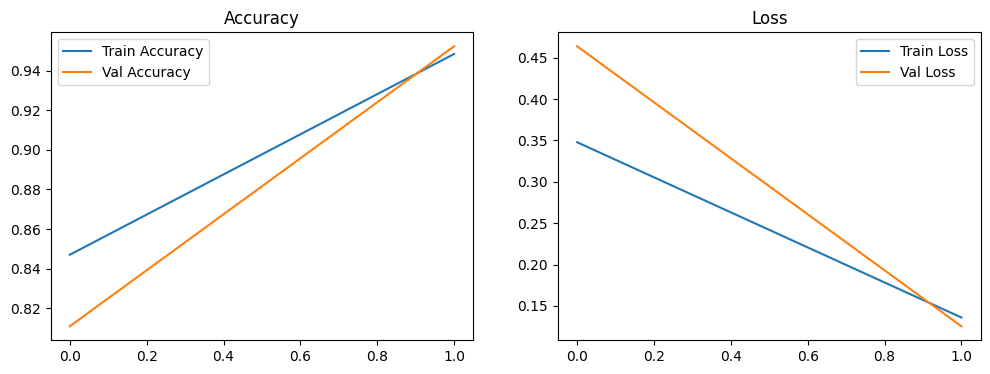

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
model = tf.keras.models.load_model('best_model.h5')
def predict_deepfake(image):
    # Resize and preprocess the image
    img = cv2.resize(image, (input_size, input_size))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    # Make prediction
    pred = model.predict(img)[0][0]
    label = "Fake" if pred < 0.1 else "Real"
    confidence = 1 - pred if label == "Real" else pred
    return f"Prediction: {label}\nConfidence: {confidence:.4f}"

In [ ]:
import cv2
import gradio as gr

In [ ]:
interface = gr.Interface(
    fn=predict_deepfake,
    inputs=gr.Image(type="numpy", label="Upload an Image"),
    outputs=gr.Textbox(label="Result"),
    title="Deepfake Image Detector",
    description="Upload an image to check if it's real or a deepfake. Optimized for low-resolution images."
)

# Launch the interface
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2e6659a7465898d384.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
